# 38 — Structure **reduction**: how much to prune is a **conviction** decision

**Where this sits (nb38 of nb38–41).** The paper's engine is structure learning — a paradigm is a
Bayes net revised by **expansion** (wake a node, nb39) and **reduction** (prune the couplings the
data drop, the cheap closed-form Eq. 5). This notebook is the removal half, and it answers a
question the first cut left open: when Bayesian Model Reduction wants to prune *most* of an
over-wired paradigm, **is that bad?**

**No — it depends on conviction, and that is the point.** The evidence ΔF says which edges are
*redundant*; whether the agent acts on it is set by the **value** it attaches to its structure —
the paper's value-tilted revision objective

$$\mathcal F[q] = D_{\mathrm{KL}}\!\big(q \,\|\, p(s\mid o)\big) - \lambda\,\mathbb E_q[U(s)],\qquad U = \mathsf T\,u .$$

So we prune an edge iff its evidence for redundancy clears its **conviction protection**:

$$\text{prune } e \iff \Delta F_e \;>\; \lambda\, v_e,\qquad v_e = \big|U_{\mathrm{parent}(e)}\big| + \big|U_{\mathrm{child}(e)}\big|,$$

with `v_e` the propagated conviction `U = T·u` on the edge (`dual_field.PrecisionUtilityNet`). The
threshold I used in the first version (`ΔF > 0.3`) was *this*, with `λ·v_e` collapsed to a constant —
**the margin was conviction in disguise.** Sweeping `λ` turns "how much to prune" into the paper's
order parameter:

* **`λ → 0` — revolution.** No value attached: prune everything the evidence finds redundant
  (including the unobservable phlogiston hub). The aggressive prune is *correct* — it is the
  Lavoisian elimination of a hidden posit the data do not need.
* **`λ` large — lock-in.** The agent values its structure and keeps it past where the evidence alone
  would drop it. Conviction sets whether the core ever moves (paper §6).

Two findings reported below: the **hub is evidence-indifferent** (the data are silent on the
unidentified core → only conviction decides it), and **prune ≠ false** (BMR removes *redundant*
edges, which is channel-dependent). §B gives the exact node removal by marginalization (Eq. 2).

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, jax, jax.numpy as jnp
import matplotlib.pyplot as plt
try:
    import networkx as nx
except Exception:
    nx = None
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from src.structural.phlogiston import (StructuralConfig, phlogiston_bn, gravimetric_H,
                                       phi_true_at, conviction_u, balanced_lambda, HUB, HUB_NEIGHBOURS)
from src.structural.bayesnet import LinearGaussianBN
from src.structural import linalg, bmr, dual_field
from src.structural.belief import GaussianBeliefNet

RESULTS = pathlib.Path(ROOT if (ROOT / 'results').exists() else ROOT.parent) / 'results' / 'structural_reduction_closeup'
RESULTS.mkdir(parents=True, exist_ok=True)
cfg = StructuralConfig(t_shift=40, n_steps=120)
bn = phlogiston_bn(cfg, conviction=2.0)        # the incumbent paradigm as explicit CPDs
names = bn.names; idx = {n: i for i, n in enumerate(names)}; d = bn.dim
print('phlogiston paradigm:', d, 'nodes,', int((np.asarray(bn.B) != 0).sum()), 'directed CPD edges')

phlogiston paradigm: 10 nodes, 10 directed CPD edges


## A directed-DAG drawer (reused across nb38–41)

`B[child, parent] ≠ 0` **is** the edge, so structure editing is literally entries appearing or
vanishing in `B`. This helper draws the DAG from `B` and tints edges **removed** (red, dashed) or
**added** (green) against a baseline.

In [2]:
def dag_layout(net, seed=4):
    if nx is None:
        th = np.linspace(0, 2*np.pi, net.dim, endpoint=False)
        return {i: (np.cos(t), np.sin(t)) for i, t in enumerate(th)}
    G = nx.DiGraph(); G.add_nodes_from(range(net.dim)); B = np.asarray(net.B)
    for v in range(net.dim):
        for u in range(net.dim):
            if abs(B[v, u]) > 1e-9: G.add_edge(u, v)
    return nx.spring_layout(G, seed=seed, k=1.4)

def draw_dag(ax, net, pos, title, *, node_vals=None, removed=frozenset(), added=frozenset(),
             thr=0.05, label_nodes=True):
    B = np.asarray(net.B); nm = net.names; xy = np.array([pos[i] for i in range(net.dim)])
    for v in range(net.dim):
        for u in range(net.dim):
            e = (nm[u], nm[v]); present = abs(B[v, u]) > thr
            if not present and e not in added and e not in removed: continue
            if e in removed:   color, ls, lw, a = 'crimson', (0, (3, 2)), 2.2, 0.9
            elif e in added:   color, ls, lw, a = 'seagreen', '-', 2.4, 0.95
            else:              color, ls, lw, a = '0.6', '-', 1.0 + 2.0*min(abs(B[v, u]), 1.0), 0.7
            ax.annotate('', xy=xy[v], xytext=xy[u],
                        arrowprops=dict(arrowstyle='-|>', color=color, lw=lw, ls=ls, alpha=a, shrinkA=11, shrinkB=11))
    vals = np.zeros(net.dim) if node_vals is None else np.asarray(node_vals)
    sc = ax.scatter(xy[:, 0], xy[:, 1], c=vals, cmap='coolwarm', s=430, vmin=-1.5, vmax=1.5,
                    edgecolor='black', linewidth=0.6, zorder=3)
    if label_nodes:
        for i, n in enumerate(nm):
            ax.text(xy[i, 0], xy[i, 1] - 0.13, n if len(n) <= 12 else n[:11]+'…', ha='center', va='top', fontsize=6, zorder=4)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal'); ax.margins(0.18)
    return sc

## A — Over-wire the paradigm, then read off the evidence and the conviction

Four **spurious** directed edges the phlogiston prior never had. The evidence `ΔF` (closed-form
BMR) says which edges are redundant; the conviction field `U = T·u` (value toward the phlogiston
reading of the contested mass law) says how strongly each edge is *protected*.

In [3]:
spurious = [('combustion_releases', 'mass_change_sign', 0.6),
            ('calcination_releases', 'reduction_with_charcoal', 0.6),
            ('air_has_capacity', 'respiration_like_combustion', 0.6),
            ('combustion_releases', 'calx_heavier_than_metal', 0.5)]
B = np.asarray(bn.B).copy()
for p, c, w in spurious: B[idx[c], idx[p]] = w
over = LinearGaussianBN(B=jnp.asarray(B), b=bn.b, s=bn.s, names=names)
all_edges = [(names[u], names[v]) for v in range(d) for u in range(d) if abs(B[v, u]) > 1e-9]
spur_edges = [(p, c) for p, c, _ in spurious]

# accumulate the regime-switching gravimetric evidence
Hg = gravimetric_H(cfg); gbn = over.to_info(); Pi = gbn.Pi; h = gbn.h; key = jax.random.PRNGKey(1)
for t in range(cfg.n_steps):
    phi = phi_true_at(cfg, t); key, k = jax.random.split(key)
    o = Hg @ phi + 0.1 * jax.random.normal(k, (Hg.shape[0],))
    Jd, jd = linalg.fisher_deposit(Hg, o, cfg.sigma_o); Pi = Pi + Jd; h = h + jd
lik = (Pi - gbn.Pi, h - gbn.h)

# evidence ΔF and conviction protection v_e per edge
dF = {(p, c): float(over.bmr_prune_edge(c, p, likelihood=lik)['delta_F']) for (p, c) in all_edges}
u = conviction_u(cfg, 'phlogiston')                         # value the contested mass-law reading
pun = dual_field.PrecisionUtilityNet(names=names, Pi=gbn.Pi, h=gbn.h, u=u, alpha=0.5)
U = np.abs(np.asarray(pun.effective_utility()))             # |propagated conviction| per node, U = T u
v_e = {(p, c): float(U[idx[p]] + U[idx[c]]) for (p, c) in all_edges}
lstar = balanced_lambda(cfg, 'phlogiston')
print(f'over-wired: {len(all_edges)} edges ({len(all_edges)-len(spur_edges)} genuine + {len(spur_edges)} spurious); balanced λ* = {lstar:.2f}')
print('most-protected edges (high v_e = the valued contested mass law):',
      [f'{p}→{c}' for (p, c) in sorted(all_edges, key=lambda e: -v_e[e])[:3]])

over-wired: 14 edges (10 genuine + 4 spurious); balanced λ* = 0.69
most-protected edges (high v_e = the valued contested mass law): ['mass_change_sign→calx_heavier_than_metal', 'gas_consumed→calx_heavier_than_metal', 'combustion_releases→calx_heavier_than_metal']


### A1 — The two ledgers: evidence `ΔF` and conviction protection `λ·v_e`

Each edge carries an evidence-for-pruning `ΔF` (grey) and a conviction protection `v_e` (the
propagated value `U=T·u`, gold). An edge is pruned only where the grey bar **out-reaches** the gold
one. Note the contested **belt** edges (`mass→calx`, `gas→calx`) carry the *most* conviction — they
encode the phlogiston mass-law reading the community values — so they are the hardest to drop, even
though the evidence finds them redundant.

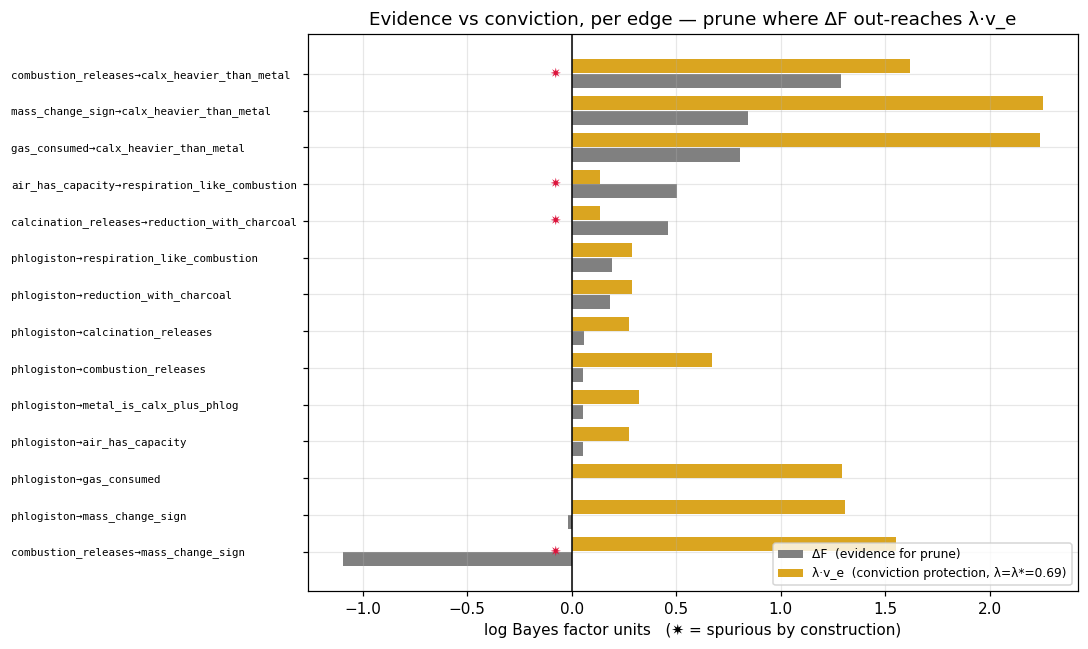

In [4]:
LAMBDA = lstar                                              # the reference conviction tilt for the ledger
order = sorted(all_edges, key=lambda e: dF[e])
y = np.arange(len(order)); labels = [f'{p}→{c}' for p, c in order]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y - 0.2, [dF[e] for e in order], height=0.38, color='0.5', label='ΔF  (evidence for prune)')
ax.barh(y + 0.2, [LAMBDA * v_e[e] for e in order], height=0.38, color='goldenrod',
        label=f'λ·v_e  (conviction protection, λ=λ*={LAMBDA:.2f})')
for i, e in enumerate(order):
    if e in spur_edges: ax.text(-0.05, y[i], '✷', ha='right', va='center', fontsize=9, color='crimson')
ax.axvline(0, color='k', lw=1)
ax.set_yticks(y); ax.set_yticklabels([f'{l:<44}' for l in labels], fontsize=7, family='monospace')
ax.set_xlabel('log Bayes factor units   (✷ = spurious by construction)')
ax.set_title('Evidence vs conviction, per edge — prune where ΔF out-reaches λ·v_e')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.savefig(RESULTS / 'A1_evidence_vs_conviction.png'); plt.show()

### A2 — Sweep the conviction tilt λ: revolution → lock-in

The order parameter. At `λ = 0` (no value attached) the agent prunes everything the evidence finds
redundant — the **revolution**, and the aggressive prune is *correct*. As `λ` rises the agent
protects its valued structure and keeps more, until at high `λ` it keeps the whole over-wired net —
**lock-in**. The prune **order** is periphery-first / contested-core-last: cheap unvalued junk goes
first, the contested mass-law structure last.

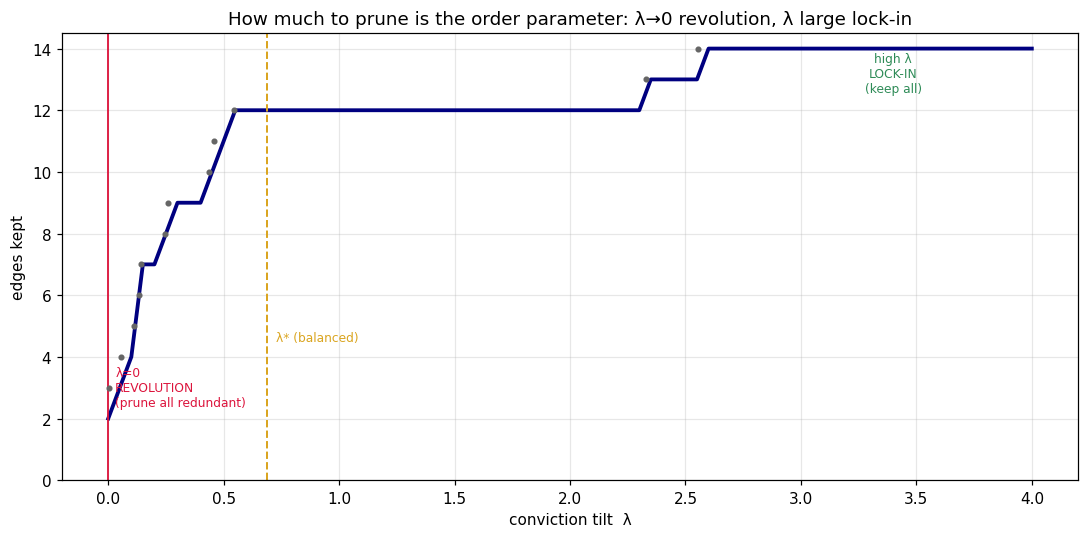

  λ= 0.00: keep  2/14 edges
  λ= 0.25: keep  8/14 edges
  λ= 0.69: keep 12/14 edges
  λ= 1.00: keep 12/14 edges
  λ= 4.00: keep 14/14 edges


In [5]:
lams = np.linspace(0, 4.0, 81)
kept_counts = [sum(1 for e in all_edges if not (dF[e] > lam * v_e[e])) for lam in lams]
# the λ at which each edge crosses from pruned to kept (= dF/v_e), for the rug
cross = sorted((dF[e] / v_e[e], e) for e in all_edges if dF[e] > 0)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lams, kept_counts, lw=2.5, color='navy')
ax.axvline(0, color='crimson', lw=1.2); ax.text(0.03, 3, 'λ=0\nREVOLUTION\n(prune all redundant)', color='crimson', fontsize=8, va='center')
ax.text(3.4, len(all_edges)-1.4, 'high λ\nLOCK-IN\n(keep all)', color='seagreen', fontsize=8, ha='center')
ax.axvline(lstar, color='goldenrod', ls='--', lw=1.3); ax.text(lstar+0.04, 4.5, 'λ* (balanced)', color='goldenrod', fontsize=8)
for ratio, e in cross:
    ax.plot([ratio], [sum(1 for ee in all_edges if not (dF[ee] > ratio*1.0001*v_e[ee]))], 'o', ms=3, color='0.4')
ax.set_xlabel('conviction tilt  λ'); ax.set_ylabel('edges kept'); ax.set_ylim(0, len(all_edges)+0.5)
ax.set_title('How much to prune is the order parameter: λ→0 revolution, λ large lock-in')
plt.tight_layout(); plt.savefig(RESULTS / 'A2_conviction_sweep.png'); plt.show()
for lam in [0.0, 0.25, lstar, 1.0, 4.0]:
    kept = sum(1 for e in all_edges if not (dF[e] > lam * v_e[e]))
    print(f'  λ={lam:5.2f}: keep {kept:2d}/{len(all_edges)} edges')

### A3 — The two regimes drawn: revolution vs lock-in

The committed Bayes net at low conviction (`λ≈0`, the structure carved to almost nothing — the
phlogiston posit eliminated) and at high conviction (`λ` large, the over-wired structure retained
whole). Pruned edges are red-dashed where they were.

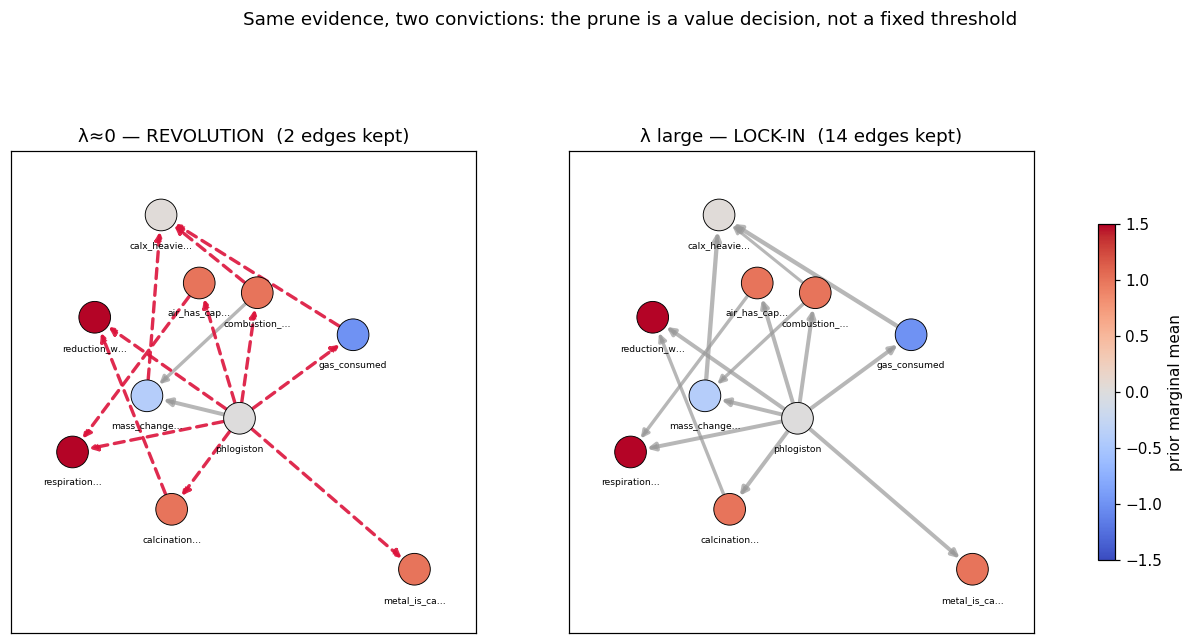

In [6]:
def pruned_at(lam): return {e for e in all_edges if dF[e] > lam * v_e[e]}
pos = dag_layout(over, seed=4); mu_prior = np.asarray(over.joint()[0])
fig, axs = plt.subplots(1, 2, figsize=(15, 6.6))
for ax, lam, ttl in [(axs[0], 0.0, 'λ≈0 — REVOLUTION'), (axs[1], 4.0, 'λ large — LOCK-IN')]:
    rem = pruned_at(lam)
    sc = draw_dag(ax, over, pos, f'{ttl}  ({len(all_edges)-len(rem)} edges kept)', node_vals=mu_prior, removed=rem)
fig.colorbar(sc, ax=axs, shrink=0.6, label='prior marginal mean')
fig.suptitle('Same evidence, two convictions: the prune is a value decision, not a fixed threshold', y=1.02)
plt.savefig(RESULTS / 'A3_revolution_vs_lockin.png', bbox_inches='tight'); plt.show()

### A4 — Removal over time for a skeptic and a zealot

Two agents on the same evidence stream: a low-conviction **skeptic** (`λ = 0.1`) and a high-conviction
**zealot** (`λ = 2.0`). At each step we re-score every edge against the data so far and count what
each agent still keeps. The skeptic prunes the redundant structure as evidence accumulates; the
zealot holds it. (This is the single-agent seed of the population in nb42.)

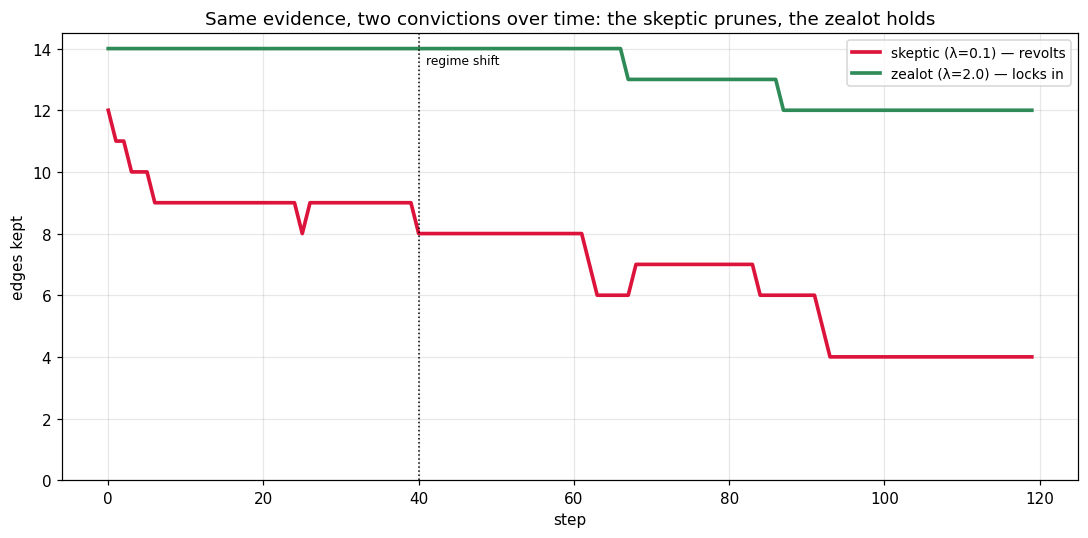

end: skeptic keeps 4/14, zealot keeps 12/14


In [7]:
from src.structural import plot
Hg = gravimetric_H(cfg); Jt = jnp.zeros((d, d)); jt = jnp.zeros(d); key = jax.random.PRNGKey(1)
keep_skeptic, keep_zealot = [], []
LAM_LO, LAM_HI = 0.1, 2.0
for t in range(cfg.n_steps):
    phi = phi_true_at(cfg, t); key, k = jax.random.split(key)
    o = Hg @ phi + 0.1 * jax.random.normal(k, (Hg.shape[0],))
    Jd, jd = linalg.fisher_deposit(Hg, o, cfg.sigma_o); Jt = Jt + Jd; jt = jt + jd
    dFt = {e: float(over.bmr_prune_edge(e[1], e[0], likelihood=(Jt, jt))['delta_F']) for e in all_edges}
    keep_skeptic.append(sum(1 for e in all_edges if not (dFt[e] > LAM_LO * v_e[e])))
    keep_zealot.append(sum(1 for e in all_edges if not (dFt[e] > LAM_HI * v_e[e])))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(keep_skeptic, lw=2.4, color='crimson', label=f'skeptic (λ={LAM_LO}) — revolts')
ax.plot(keep_zealot, lw=2.4, color='seagreen', label=f'zealot (λ={LAM_HI}) — locks in')
ax.axvline(cfg.t_shift, color='k', ls=':', lw=1); ax.text(cfg.t_shift+1, len(all_edges)-0.5, 'regime shift', fontsize=8)
ax.set_xlabel('step'); ax.set_ylabel('edges kept'); ax.set_ylim(0, len(all_edges)+0.5)
ax.set_title('Same evidence, two convictions over time: the skeptic prunes, the zealot holds')
ax.legend(fontsize=9); plt.tight_layout(); plt.savefig(RESULTS / 'A4_skeptic_vs_zealot_time.png'); plt.show()
print(f'end: skeptic keeps {keep_skeptic[-1]}/{len(all_edges)}, zealot keeps {keep_zealot[-1]}/{len(all_edges)}')

## B — The hub is evidence-indifferent: only conviction can decide it

Before the clean node removal, the finding that *forces* the conviction reading. The phlogiston hub
is **never observed**, so the data cannot say whether to keep it: the log Bayes factor for
eliminating the whole hub node sits at `ΔF ≈ 0` no matter how much of the disconfirming
(mass-balance) channel we let through. The evidence is silent on the unidentified core — so its fate
is a *pure conviction* call, exactly the §6 claim that conviction sets whether the core moves.

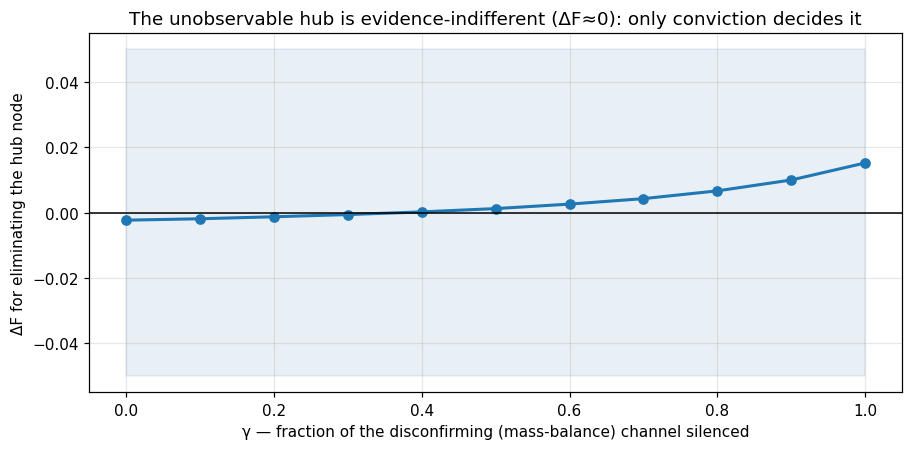

hub-elimination ΔF across all γ: [-0.002, -0.002, -0.001, -0.001, 0.0, 0.001, 0.003, 0.004, 0.007, 0.01, 0.015] — all ≈ 0


In [8]:
from src.structural.phlogiston import gravimetric_rows
prior = bn.to_info(); reduced_prior = bmr.prune_node_prior(prior, (HUB,))
Hgn = np.asarray(gravimetric_H(cfg)); rows = gravimetric_rows(cfg)
disc = [i for i, r in enumerate(rows) if 'mass_balance' in r][0]
gammas = np.linspace(0, 1, 11); dF_hub = []
for gamma in gammas:
    w = np.ones(Hgn.shape[0]); w[disc] = 1.0 - gamma
    Pg = prior.Pi; hg = prior.h; key = jax.random.PRNGKey(1)
    for t in range(cfg.n_steps):
        phi = phi_true_at(cfg, t); key, k = jax.random.split(key)
        o = Hgn @ phi + 0.1 * jax.random.normal(k, (Hgn.shape[0],))
        Jd, jd = linalg.fisher_deposit_weighted(jnp.asarray(Hgn), jnp.asarray(o), cfg.sigma_o, jnp.asarray(w))
        Pg = Pg + Jd; hg = hg + jd
    dF_hub.append(float(bmr.bmr_prune(GaussianBeliefNet(Pi=Pg, h=hg, names=names), prior, reduced_prior)['delta_F']))
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.plot(gammas, dF_hub, 'o-', lw=2); ax.axhline(0, color='k', lw=1)
ax.fill_between(gammas, -0.05, 0.05, color='steelblue', alpha=0.12)
ax.set_xlabel('γ — fraction of the disconfirming (mass-balance) channel silenced')
ax.set_ylabel('ΔF for eliminating the hub node')
ax.set_title('The unobservable hub is evidence-indifferent (ΔF≈0): only conviction decides it')
plt.tight_layout(); plt.savefig(RESULTS / 'B1_hub_evidence_indifferent.png'); plt.show()
print('hub-elimination ΔF across all γ:', [round(x, 3) for x in dF_hub], '— all ≈ 0')

### B2 — The exact node removal: marginalizing the hub (Eq. 2)

When conviction *does* let the hub go, the removal is exact. Marginalizing `phlogiston`
(`schur_marginalize`) deletes the node and its star — but the correlation it carried **condenses**
into a clique among its former neighbours (the carry-over fill-in `−Π_ab Π_bb⁻¹ Π_ba`, Eq. 2). The
star becomes a clique: incommensurability as the Schur residue.

marginalize the hub: 10 → 9 nodes; star (degree 8) → ~28 induced couplings (carry-over clique).


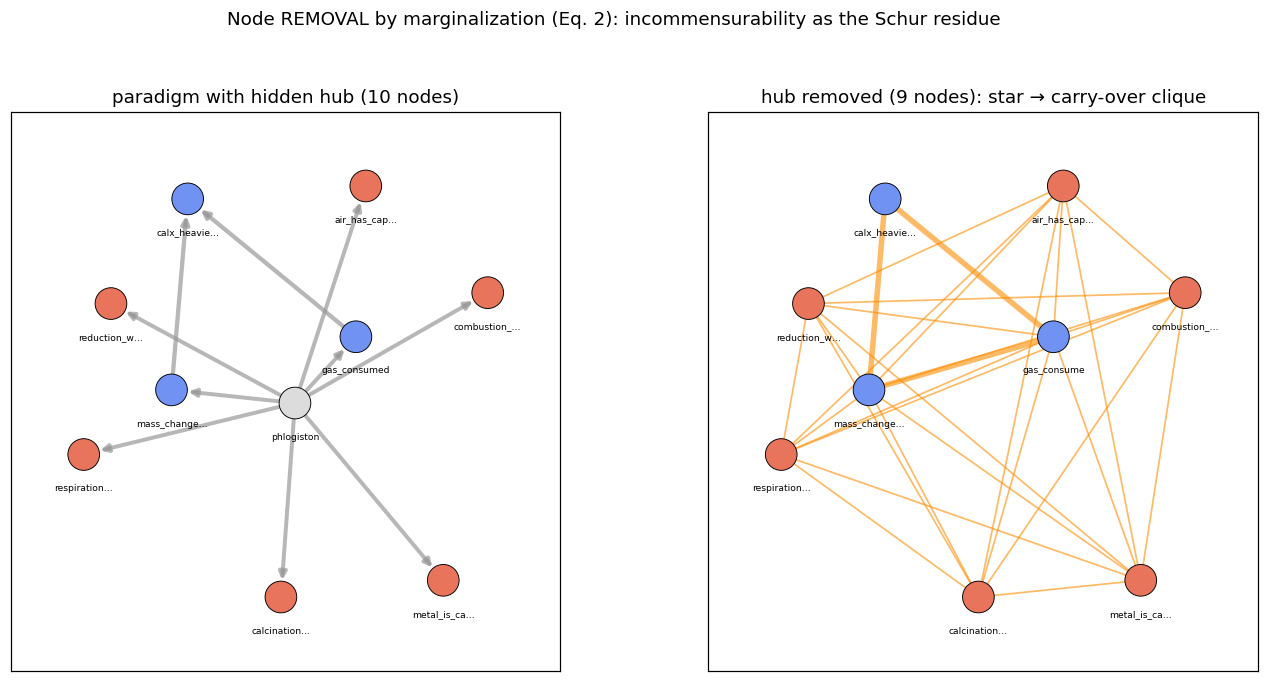

In [9]:
keep = jnp.asarray([i for i in range(d) if names[i] != HUB]); drop = jnp.asarray([idx[HUB]])
Pi_marg, h_marg = linalg.schur_marginalize(prior.Pi, prior.h, keep, drop)
kept_names = tuple(n for n in names if n != HUB)
fill = np.abs(np.asarray(linalg.carryover_fillin(prior.Pi, keep, drop)))
induced = int((fill[np.triu_indices(len(kept_names), 1)] > 0.05).sum())
print(f'marginalize the hub: {d} → {len(kept_names)} nodes; star (degree {len(HUB_NEIGHBOURS)}) → ~{induced} induced couplings (carry-over clique).')
pos_full = dag_layout(bn, seed=4)
fig, axs = plt.subplots(1, 2, figsize=(15, 6.6))
draw_dag(axs[0], bn, pos_full, f'paradigm with hidden hub ({d} nodes)', node_vals=np.asarray(bn.joint()[0]))
posm = {i: pos_full[idx[n]] for i, n in enumerate(kept_names)}
Pim = np.abs(np.asarray(Pi_marg)).copy(); np.fill_diagonal(Pim, 0)
xy = np.array([posm[i] for i in range(len(kept_names))])
for a in range(len(kept_names)):
    for b in range(a+1, len(kept_names)):
        if Pim[a, b] > 0.05:
            axs[1].plot([xy[a,0], xy[b,0]], [xy[a,1], xy[b,1]], color='darkorange', lw=0.6+3*min(Pim[a,b],1.0), alpha=0.6, zorder=1)
axs[1].scatter(xy[:,0], xy[:,1], c=np.asarray(linalg.info_mean(Pi_marg, h_marg)), cmap='coolwarm',
               s=430, vmin=-1.5, vmax=1.5, edgecolor='k', lw=0.6, zorder=3)
for i, n in enumerate(kept_names):
    axs[1].text(xy[i,0], xy[i,1]-0.13, n[:11]+('…' if len(n) > 12 else ''), ha='center', va='top', fontsize=6, zorder=4)
axs[1].set_title(f'hub removed ({len(kept_names)} nodes): star → carry-over clique')
axs[1].set_xticks([]); axs[1].set_yticks([]); axs[1].set_aspect('equal'); axs[1].margins(0.18)
fig.suptitle('Node REMOVAL by marginalization (Eq. 2): incommensurability as the Schur residue', y=1.02)
plt.savefig(RESULTS / 'B2_node_removal_marginalization.png', bbox_inches='tight'); plt.show()

## Verdict

Reduction, reframed: **how much to prune is a conviction decision**, on the existing classes
(`bayesnet.LinearGaussianBN` + `dual_field` + `bmr`):

* the evidence ΔF (closed-form BMR, Eq. 5) finds the **redundant** edges; conviction `U = T·u`
  (`dual_field`) sets their **protection** `v_e`, and the agent prunes iff `ΔF_e > λ·v_e` — the
  value-tilted objective of Eqs. (7)–(8). The ad-hoc margin of v1 was this with `λ·v_e` flattened to
  a constant: **the margin was conviction**;
* sweeping `λ` is the **order parameter** (§A2): `λ→0` is the **revolution** (the aggressive prune
  is *correct* — eliminate the structure the data do not need), `λ` large is **lock-in** (keep it),
  and the order is periphery-first / contested-core-last;
* the **hub is evidence-indifferent** (§B1, ΔF≈0 at every disconfirming weight) — the data are
  silent on the unidentified core, so *only* conviction can decide it; and when it is let go, the
  removal is the exact Eq. 2 marginalization, star → carry-over clique (§B2);
* **prune ≠ false**: BMR removes the *redundant* edges, channel- and correlation-dependent — a true
  belt edge retired by the relational channel, a spurious one kept by the hidden hub's correlation.

Next: nb39 (addition), and **nb42** runs this conviction-gated reduction across a **population** —
where the spread of `λ` becomes the stratified revolution-vs-lock-in of §6.